[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bsheese/225/blob/main/11_time/11_4_Period_Comparisons.ipynb)

# 11.4: Period-over-Period Comparisons

The rolling mean in notebook 11.3 shows you the trend: ridership goes up in summer and down in winter. But it does not tell you how fast the trend is changing, or whether this August was growing faster than last August. For that you need to compare each period to the period before it.

Two pandas methods handle this. `.diff()` computes the absolute change between consecutive rows. `.pct_change()` computes the same change as a fraction of the earlier value. Both produce a series of the same length as the input, where each value answers the question "how did this period compare to the one before it?"

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

url = "https://raw.githubusercontent.com/bsheese/225/main/data/bike_daily.csv"
keep = ["dteday", "season", "yr", "mnth", "holiday", "weekday",
        "workingday", "weathersit", "temp", "casual", "registered", "cnt"]
df = pd.read_csv(url, usecols=keep, parse_dates=["dteday"],
                 index_col="dteday").sort_index()
df.head()

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,casual,registered,cnt
dteday,,,,,,,,,,,
2011-01-01,1,0,1,0,6,0,2,0.344167,331,654,985
2011-01-02,1,0,1,0,0,0,2,0.363478,131,670,801
2011-01-03,1,0,1,0,1,1,1,0.196364,120,1229,1349
2011-01-04,1,0,1,0,2,1,1,0.200000,108,1454,1562
2011-01-05,1,0,1,0,3,1,1,0.226957,82,1518,1600


## Day-over-day absolute change with `.diff()`

`.diff()` subtracts the previous row from the current row. For rental counts, each value in the result tells you how many more (or fewer) bikes were rented today compared to yesterday.

In [2]:
day_diff = df["cnt"].diff()
print("First 5 values:")
print(day_diff.head().to_string())
print()
print("Largest one-day drop:")
print(day_diff.idxmin(), int(day_diff.min()))

First 5 values:
dteday
2011-01-01      NaN
2011-01-02   -184.0
2011-01-03    548.0
2011-01-04    213.0
2011-01-05     38.0

Largest one-day drop:
2012-04-22 00:00:00 -5597


The first row is `NaN` because there is no "day before" January 1, 2011. After that, each value tells you the net change from the previous day. Large negative values are days when ridership fell sharply; large positive values are strong rebound days.

> April 22, 2012 is Earth Day. The dataset's documentation notes that a large outdoor festival on the National Mall on April 21 drove unusually high ridership that day, which then plunged back on April 22. The `.diff()` series has no way to know this. It just records a drop of 5,597. Whenever a single date stands out this sharply, it is worth checking the calendar before drawing conclusions from the number alone.

## Finding the date of a peak or drop: `.idxmax()` and `.idxmin()`

`.min()` and `.max()` return the smallest and largest values in a series. For time-series data you usually care more about *when* the extreme happened. `.idxmin()` returns the index label of the minimum, and `.idxmax()` returns the index label of the maximum. When the index is a `DatetimeIndex`, those labels are timestamps.

Calling `.date()` on the result trims the timestamp to just the calendar date, which is usually the form you want to display.

In [3]:
print("Day with most rentals:   ", df["cnt"].idxmax().date(), "->", df["cnt"].max())
print("Day with fewest rentals: ", df["cnt"].idxmin().date(), "->", df["cnt"].min())
print()
print("Largest one-day drop:    ", day_diff.idxmin().date(), "->", int(day_diff.min()))
print("Largest one-day gain:    ", day_diff.idxmax().date(), "->", int(day_diff.max()))

Day with most rentals:    2012-09-15 -> 8714
Day with fewest rentals:  2012-10-29 -> 22

Largest one-day drop:     2012-04-22 -> -5597
Largest one-day gain:     2012-10-31 -> 4470


September 15, 2012 was the single busiest day. October 29, 2012 was the lowest, the date Hurricane Sandy hit the Washington DC area and shut down the city. The largest one-day drop is April 22, 2012 (Earth Day, as noted above); the largest one-day gain is October 31, 2012, the day after Sandy passed and ridership rebounded sharply.

## Day-over-day percent change with `.pct_change()`

Absolute change has a scale problem. A drop of 500 rentals means something different in January (when baseline is ~1,000) than in July (when baseline is ~7,000). `.pct_change()` expresses the change as a fraction of the earlier value, making it comparable across seasons.

In [4]:
day_pct = df["cnt"].pct_change()

# Show a few rows
print(day_pct.head(8).round(3).to_string())
print()
# Distribution of daily changes
print("Typical daily change (median): {:.1%}".format(day_pct.median()))
print("Standard deviation:            {:.1%}".format(day_pct.std()))

dteday
2011-01-01      NaN
2011-01-02   -0.187
2011-01-03    0.684
2011-01-04    0.158
2011-01-05    0.024
2011-01-06    0.004
2011-01-07   -0.060
2011-01-08   -0.365

Typical daily change (median): 1.1%
Standard deviation:            186.3%


The median daily change is close to zero, which makes sense: most days are similar to the day before. The standard deviation is large because individual days can swing dramatically when weather changes suddenly. These day-to-day swings are noise, not trend. To see meaningful change, we need to resample first.

## Month-over-month change

Resampling to monthly totals first, then calling `.pct_change()`, answers a more useful question: how did this month compare to last month?

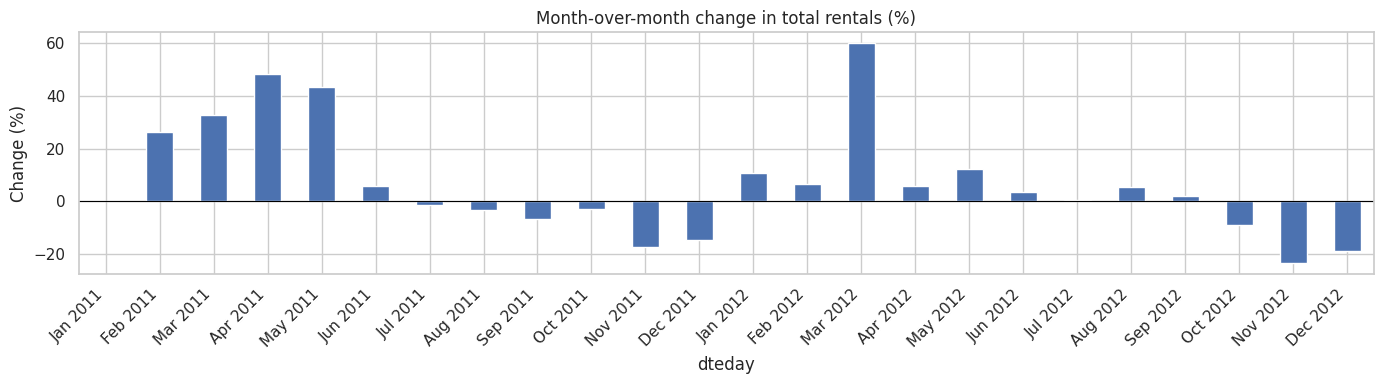

In [5]:
monthly = df["cnt"].resample("ME").sum()
mom = monthly.pct_change()

# Bar chart of month-over-month change
ax = mom.mul(100).plot(kind="bar", figsize=(14, 4),
                       title="Month-over-month change in total rentals (%)")
ax.set_ylabel("Change (%)")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticklabels([d.strftime("%b %Y") for d in mom.index], rotation=45, ha="right")
plt.tight_layout()

The biggest month-over-month jump is March 2012, at roughly 60 percent, when ridership surges out of winter. April and May 2011 also show large gains (around 48 and 43 percent) for the same reason. The steepest drops are November 2012, at around negative 23 percent, and December 2012, at around negative 19 percent, when cold weather sharply reduces casual ridership. The first row (January 2011) shows no bar because there is no December 2010 to compare against.

## Year-over-year change

`.pct_change(12)` shifts by 12 rows instead of 1. On monthly data, that means each month is compared to the same month one year earlier, removing the seasonal effect and showing true year-over-year growth.

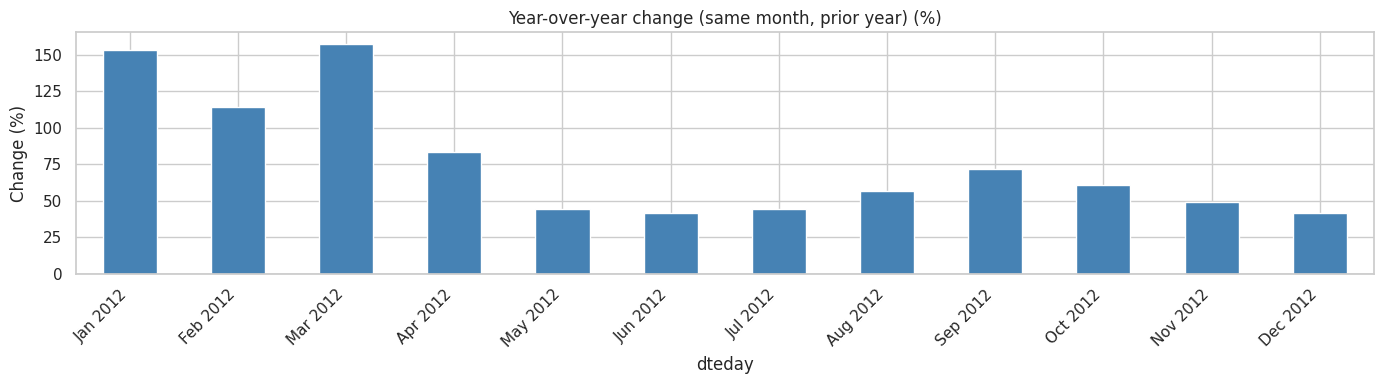

In [6]:
yoy = monthly.pct_change(12)

# Only show months where we have a year-ago comparison (13 months onward)
ax = yoy.dropna().mul(100).plot(kind="bar", figsize=(14, 4),
                                title="Year-over-year change (same month, prior year) (%)",
                                color="steelblue")
ax.set_ylabel("Change (%)")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticklabels([d.strftime("%b %Y") for d in yoy.dropna().index], rotation=45, ha="right")
plt.tight_layout()

Every bar is positive: 2012 had more rentals in every month than the same month in 2011. Growth was exceptionally high in the winter and early spring of 2012 (January through March: roughly 114 to 157 percent above the prior year), because the program was still small in early 2011. The advantage then narrowed to its smallest in late spring and early summer, near 41 percent by June, when the 2011 baseline was already strong, before widening again to about 72 percent in September. The earliest months were the easiest to beat because the 2011 baseline was tiny, which is common in young programs that grow quickly in their first year; the later month-to-month bumpiness reflects how much each month's 2011 baseline had already grown. The first twelve months of the result are NaN because there is no year-ago data for 2011 itself.

## What's next

You can now measure how fast things are changing and compare periods across years. What you have not yet asked is whether the patterns repeat by season, day of week, or month. In notebook 11.5 you will read time components from the index and use groupby to find those recurring structures.